# Machine Learning Foundations for Risk and Finance
## Week 2 - Classification & Risk Management
### A Tale of Defaults, Fraud, and Decision Boundaries

In Week 1, we predicted continuous values (sales, prices).

In Week 2, we face a different challenge: **Classification**.

In Finance, this usually means making a binary decision:
* **Buy or Sell?** (Trading)
* **Default or Repay?** (Credit Risk)
* **Fraud or Legit?** (Cybersecurity)

This notebook explores how different algorithms try to draw a "line" (Decision Boundary)
between these two classes.

We will cover:

| Part | Topic | Slides |
|---|---|---|
| **1** | Two datasets: a credit book and a fraud ring | - |
| **2** | Logistic regression, regularization, and the polynomial trick | 65-77 |
| **3** | Evaluating risk models - why accuracy is dangerous | 38-41 |
| **4** | KNN, the units problem, and choosing k honestly | 78-86 |
| **5** | The decision threshold, costs, and what a probability is worth | 87-90 |

Four claims run through this notebook that are easy to state and easy to accept without
evidence: that a 99%-accurate model can be useless, that features must be rescaled before
KNN, that small k overfits, and that 0.5 is the wrong place to cut a probability. We
**measure** all four rather than asserting them, and one of them turns out to need a
caveat.

## Library Import

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from sklearn.datasets import make_blobs, make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.calibration import calibration_curve
from sklearn.metrics import (confusion_matrix, classification_report, roc_curve, auc,
                             ConfusionMatrixDisplay, accuracy_score, recall_score,
                             roc_auc_score, brier_score_loss)

import sklearn
print('scikit-learn', sklearn.__version__)

# scikit-learn 1.8 deprecated the `penalty=` argument of LogisticRegression. We keep using
# it (see the note in the next cell) so this notebook runs identically on every version you
# are likely to have, and we silence that ONE message so the output stays readable.
# Nothing else is suppressed - if you see a warning below, it is a real one.
import warnings
warnings.filterwarnings('ignore', message=".*'penalty' was deprecated.*")
warnings.filterwarnings('ignore', message=".*Inconsistent values: penalty.*")

scikit-learn 1.8.0


> ### A note on `penalty=` (read this before the homework)
>
> As of **scikit-learn 1.8** the `penalty` argument of `LogisticRegression` is deprecated and
> will be **removed in 1.10**. The replacement is `l1_ratio`:
>
> | old | new |
> |---|---|
> | `penalty='l2'` | `l1_ratio=0` (this is the default) |
> | `penalty='l1'` | `l1_ratio=1` |
> | `penalty=None` | `C=np.inf` |
>
> This notebook deliberately uses the **old** spelling. The reason is a trap worth knowing
> about: on scikit-learn **older than 1.8**, `l1_ratio` is ignored unless you also pass
> `penalty='elasticnet'`. So writing `l1_ratio=1` on an older install does not raise an
> error - it silently fits an **L2** model, and your "Lasso" produces no zeros at all.
>
> A warning you can see is safer than a wrong answer you cannot. Check your version in the
> cell above and use the spelling that matches it.

# Part 1: The Two Datasets

## 1.1 The "Credit Risk" Dataset (Linear Separation)
Imagine we are a bank. We have two features for our customers:
1.  **Annual Income** ($x_1$)
2.  **Existing Debt** ($x_2$)

We want to classify customers into:
* **Blue:** Safe Borrowers (High Income, Low Debt)
* **Red:** Risky Borrowers (Low Income, High Debt)

This is usually a "linearly separable" problem. A straight line can separate the rich from
the indebted.

Note the word **Normalized** on the axis labels below. Hold on to it - in section 4.4 we
take it away, and something breaks.

In [2]:
X_blob, y_blob = make_blobs(n_samples=100, centers=2,
                  random_state=100, cluster_std=7)

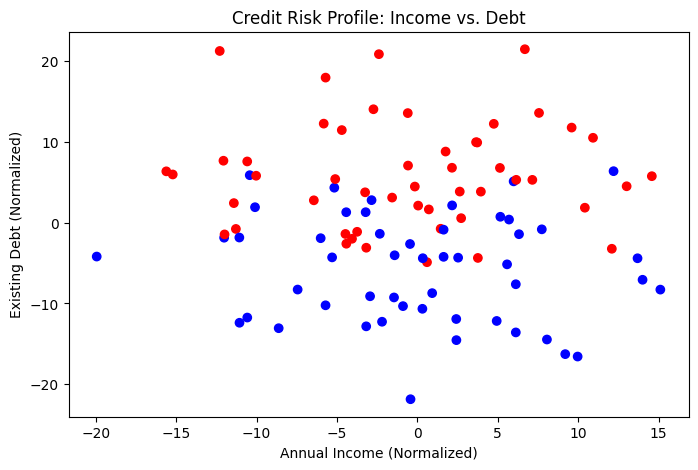

In [3]:
plt.figure(figsize=[8,5])
plt.scatter(X_blob[:,0],X_blob[:,1],c=y_blob,cmap='bwr')
plt.title("Credit Risk Profile: Income vs. Debt")
plt.xlabel("Annual Income (Normalized)")
plt.ylabel("Existing Debt (Normalized)")
plt.show()

**Observation:**
* The Blue cluster represents low risk.
* The Red cluster represents high risk.
* There is some overlap (noise), but generally, we can draw a straight line to separate them.

## 1.2 The "Fraud Ring" Dataset (Non-Linear Separation)
Now, imagine a different scenario: **Money Laundering** or **Smurfing**.
* **Legitimate transactions** (Red) cluster in the middle (normal amounts, normal times).
* **Fraudulent transactions** (Blue) occur at the extremes or surround the normal
  transactions in complex patterns (e.g. structuring / smurfing attacks).

A straight line cannot separate a circle. Linear models will fail here.

In [4]:
X_circle, y_circle = make_circles(n_samples=100, factor=.1, noise=.2,random_state=100)

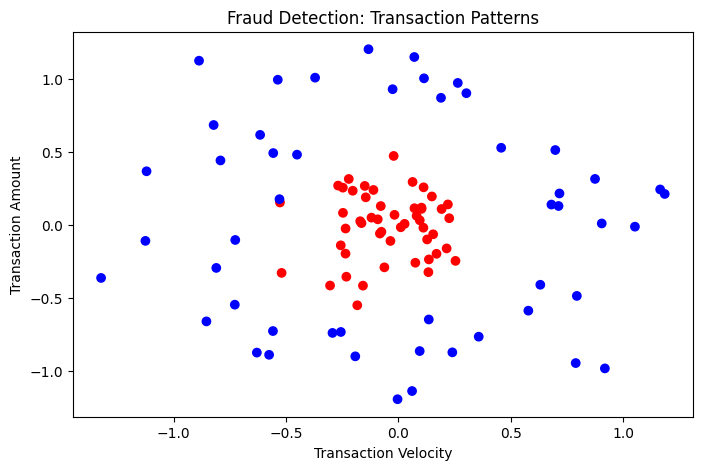

In [5]:
plt.figure(figsize=[8,5])
plt.scatter(X_circle[:,0],X_circle[:,1],c=y_circle,cmap='bwr')
plt.title("Fraud Detection: Transaction Patterns")
plt.xlabel("Transaction Velocity")
plt.ylabel("Transaction Amount")
plt.show()

**Observation:**
* Standard linear rules (e.g. "If Amount > X, then Fraud") will fail.
* We need models that can understand geometry and complex "shapes."

## 1.3 Visualizing the "Risk Boundary"
We will use this helper function to visualize how different models "think."
The line drawn is the **Decision Boundary**.
* One side is "Approve Loan" / "Legit".
* The other side is "Deny Loan" / "Fraud".

It works for any model with a `predict_proba`, including a `Pipeline`, which we need in
Part 4.

In [6]:
def plot_decision_function(model, ax=None,color='k', label=None):
    """Plot the decision boundary (Risk Threshold)"""
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # create grid to evaluate model
    x = np.linspace(xlim[0], xlim[1], 100)
    y = np.linspace(ylim[0], ylim[1], 100)
    Y, X = np.meshgrid(y, x)
    # Predict probability
    P = model.predict_proba(np.c_[X.ravel(), Y.ravel()])[:, 1].reshape(X.shape)

    # plot decision boundary (Prob = 0.5)
    output=ax.contour(X, Y, P, colors=color, levels=[0.5], linewidths=2)

    # Hack to get legend to work with contour
    if label:
        ax.plot([], [], color=color, linewidth=2, label=label)

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    return output

# Part 2: The Regulator's Favorite (Logistic Regression)

Logistic Regression is the industry standard for Credit Scoring (e.g. FICO scores).
* **Why?** It is highly interpretable. You can tell a regulator exactly *why* a loan was
  rejected ("your debt coefficient increased the probability of default by 15%").
* **Math:** It fits a "Sigmoid" (S-curve) function to squeeze output between 0 and 1
  (Probability of Default).

In production, we use Scikit-Learn. It includes **Regularization** (L1/L2) automatically.
* **L1 (Lasso):** feature selection (sets useless coefficients to 0).
* **L2 (Ridge):** stability (prevents extreme coefficients).

In Scikit-Learn, the parameter `C` controls regularization.
* **High C** = Low Regularization (trust the training data completely).
* **Low C** = High Regularization (penalize large coefficients, be conservative).

Note that `C` is the **inverse** of the alpha we used for Ridge and Lasso in Week 1. Large
alpha = strong penalty; large `C` = weak penalty. This catches everyone once.

## 2.1 No Regularization (High C)

In [7]:
log_reg_none = LogisticRegression(penalty=None)
log_reg_none.fit(X_blob, y_blob)

LogisticRegression(penalty=None)

## 2.2 Strong Regularization (Low C)

In [8]:
log_reg_reg = LogisticRegression(penalty='l2', C=0.01, solver='saga')
log_reg_reg.fit(X_blob, y_blob)

LogisticRegression(C=0.01, penalty='l2', solver='saga')

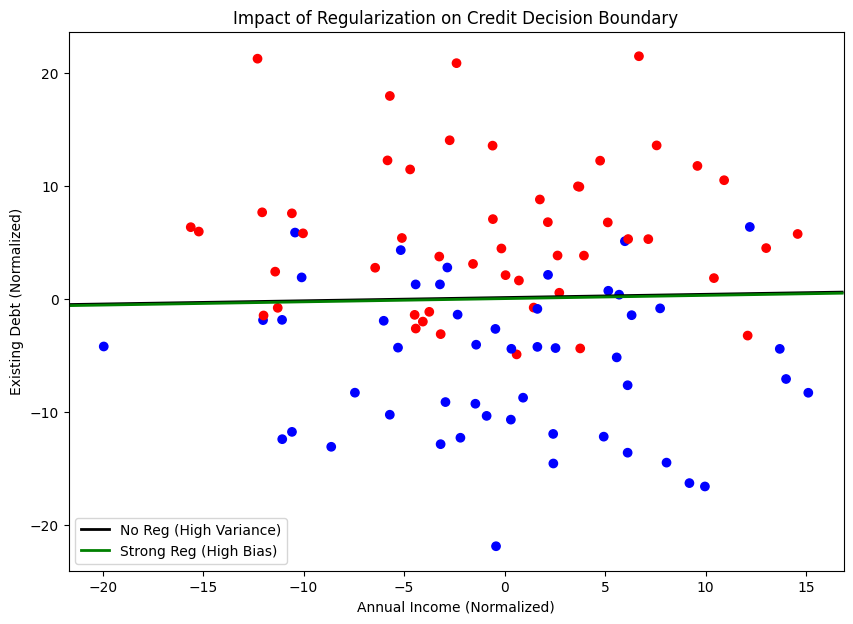

In [9]:
plt.figure(figsize=[10,7])
plt.scatter(X_blob[:,0],X_blob[:,1],c=y_blob,cmap='bwr')

plot_decision_function(log_reg_none, color='black', label='No Reg (High Variance)')
plot_decision_function(log_reg_reg, color='green', label='Strong Reg (High Bias)')
plt.xlabel("Annual Income (Normalized)")
plt.ylabel("Existing Debt (Normalized)")
plt.title("Impact of Regularization on Credit Decision Boundary")
plt.legend()
plt.show()

## 2.3 The Linear Failure (Fraud Data)
Let us see what happens when we try to fit our standard "regulator friendly" Logistic
Regression to the complex Fraud Ring data.

In [10]:
log_reg_fail = LogisticRegression(solver='saga')
log_reg_fail.fit(X_circle, y_circle)

LogisticRegression(solver='saga')

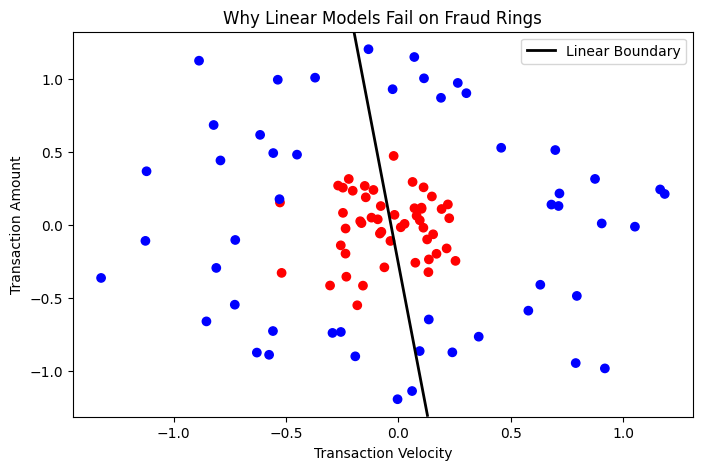

In [11]:
plt.figure(figsize=[8,5])
plt.scatter(X_circle[:,0],X_circle[:,1],c=y_circle,cmap='bwr')

# Plot the decision boundary
plot_decision_function(log_reg_fail, color='black', label='Linear Boundary')
plt.xlabel("Transaction Velocity")
plt.ylabel("Transaction Amount")
plt.title("Why Linear Models Fail on Fraud Rings")
plt.legend()
plt.show()

**Observation:** The model draws a straight line right through the middle. It
classifies half the safe transactions as fraud, and misses half the actual fraud.

We put a number on exactly how bad this is in section 4.5 - it turns out to be *worse than
a coin toss*.

## 2.4 Feature Engineering: The "Polynomial" Trick
How do we fix the Fraud problem with a linear model? We cheat.

We create **Polynomial Features** (square the data).

$x_1^2 + x_2^2 = r^2$ (Equation of a circle).

The model is still linear **in its coefficients** - it is only non-linear in the original
features. That is the whole trick, and it is the same trick as the polynomial regression in
Week 1.

In [12]:
def plot_decision_function_poly(model, poly, ax=None, color='k'):
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # Create grid to evaluate model
    x = np.linspace(xlim[0], xlim[1], 100)
    y = np.linspace(ylim[0], ylim[1], 100)
    Y, X = np.meshgrid(y, x)

    # Apply polynomial features to the grid
    XY = np.c_[X.ravel(), Y.ravel()]
    XY_poly = poly.transform(XY)

    P = model.predict_proba(XY_poly)[:, 1].reshape(X.shape)

    # Plot decision boundary
    output = ax.contour(X, Y, P, colors=color, levels=[0.5])

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    return output

In [13]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_circle)
print('original features:', X_circle.shape[1], ' ->  polynomial features:', X_poly.shape[1])
print('names:', poly.get_feature_names_out(['velocity', 'amount']))

original features: 2  ->  polynomial features: 5
names: ['velocity' 'amount' 'velocity^2' 'velocity amount' 'amount^2']


In [14]:
log_reg_blob=LogisticRegression(penalty='l2',solver='saga')
log_reg_blob.fit(X_poly, y_circle)

LogisticRegression(penalty='l2', solver='saga')

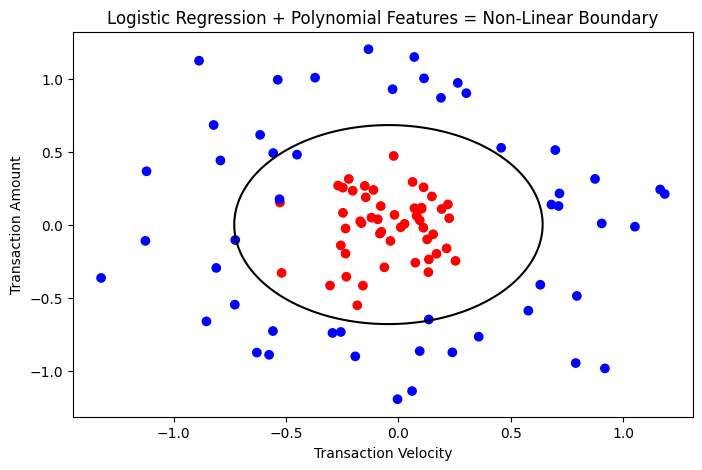

In [15]:
plt.figure(figsize=[8, 5])
plt.scatter(X_circle[:, 0], X_circle[:, 1], c=y_circle, cmap='bwr')
plot_decision_function_poly(log_reg_blob, poly, color='k')
plt.title('Logistic Regression + Polynomial Features = Non-Linear Boundary')
plt.xlabel("Transaction Velocity")
plt.ylabel("Transaction Amount")
plt.show()

## 2.5 Deep Dive: Coefficient Shrinkage (L1 vs L2)
We investigate this on the **Linear (Credit)** dataset because the coefficients are
interpretable there.

* **Ridge (L2):** shrinks all coefficients towards zero, but keeps them. Good for stability.
* **Lasso (L1):** forces weak coefficients to **exactly zero**. This performs
  **Feature Selection**.

We add four pure-noise features and see whether each penalty can tell them from the two real
ones. Two details in the setup matter, and both are easy to get wrong:

1. **The noise is seeded** (`RandomState(0)`). Without a seed the picture changes on every
   run, and you cannot discuss a plot that will not stay still.
2. **Every column is standardised first.** The two real features have a spread of about 7.5
   and 8.8; `randn` noise has a spread of 1. A penalty acts on the *size of the coefficient*,
   and the coefficient absorbs the units - so on raw data the noise columns get killed partly
   because of their scale, not because they are noise. Standardising removes that confound
   and makes it a fair fight.

**This is the same rule as the Ridge and Lasso slides in Week 1: always scale before you
penalise.**

In [16]:
C_values = np.logspace(-3, 2, 20)
coefs_l1 = []
coefs_l2 = []

rng = np.random.RandomState(0)                       # seeded: the plot is reproducible
X_noise = np.hstack([X_blob, rng.randn(100, 4)])     # 2 real features + 4 pure noise

print('column spread BEFORE scaling:', np.round(X_noise.std(axis=0), 2))
X_noise_scaled = StandardScaler().fit_transform(X_noise)
print('column spread AFTER  scaling:', np.round(X_noise_scaled.std(axis=0), 2))
print()
print('columns 0-1 are the real features, columns 2-5 are noise')

column spread BEFORE scaling: [7.49 8.77 1.08 0.97 0.89 0.97]
column spread AFTER  scaling: [1. 1. 1. 1. 1. 1.]

columns 0-1 are the real features, columns 2-5 are noise


In [17]:
for c in C_values:
    # Train Lasso (L1)
    clf_l1 = LogisticRegression(penalty='l1', C=c, solver='liblinear')
    clf_l1.fit(X_noise_scaled, y_blob)
    coefs_l1.append(clf_l1.coef_.ravel())

    # Train Ridge (L2)
    clf_l2 = LogisticRegression(penalty='l2', C=c, solver='lbfgs')
    clf_l2.fit(X_noise_scaled, y_blob)
    coefs_l2.append(clf_l2.coef_.ravel())

coefs_l1 = np.array(coefs_l1)
coefs_l2 = np.array(coefs_l2)

# how many coefficients are exactly zero at each C?
nz_l1 = (np.abs(coefs_l1) > 1e-10).sum(axis=1)
nz_l2 = (np.abs(coefs_l2) > 1e-10).sum(axis=1)
print(' %10s %16s %16s' % ('C', 'L1 non-zero /6', 'L2 non-zero /6'))
for c, a, b in zip(C_values[::3], nz_l1[::3], nz_l2[::3]):
    print(' %10.4f %12d %16d' % (c, a, b))

          C   L1 non-zero /6   L2 non-zero /6
     0.0010            0                6
     0.0062            0                6
     0.0379            1                6
     0.2336            4                6
     1.4384            6                6
     8.8587            6                6
    54.5559            6                6


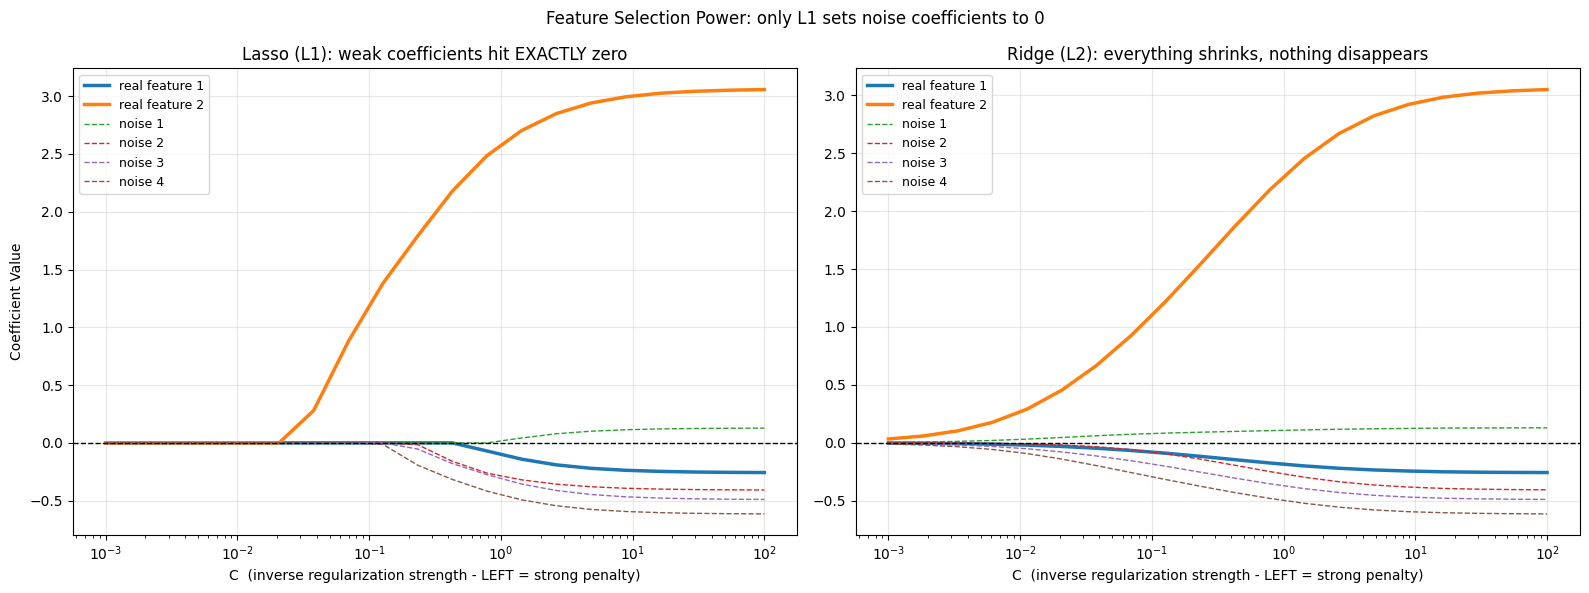

In [18]:
labels = ['real feature 1', 'real feature 2',
          'noise 1', 'noise 2', 'noise 3', 'noise 4']
styles = ['-', '-', '--', '--', '--', '--']
widths = [2.5, 2.5, 1, 1, 1, 1]

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

for j in range(6):
    ax[0].plot(C_values, coefs_l1[:, j], styles[j], lw=widths[j], label=labels[j])
    ax[1].plot(C_values, coefs_l2[:, j], styles[j], lw=widths[j], label=labels[j])

ax[0].set_title("Lasso (L1): weak coefficients hit EXACTLY zero")
ax[1].set_title("Ridge (L2): everything shrinks, nothing disappears")
for a in ax:
    a.set_xscale('log')
    a.set_xlabel("C  (inverse regularization strength - LEFT = strong penalty)")
    a.axhline(0, color='black', linestyle='--', linewidth=1)
    a.legend(fontsize=9)
    a.grid(alpha=0.3)
ax[0].set_ylabel("Coefficient Value")

plt.suptitle("Feature Selection Power: only L1 sets noise coefficients to 0")
plt.tight_layout()
plt.show()

**What to read off this plot.**

Go from **right to left** - that is the direction of increasing penalty.

* On the **left panel (L1)** the dashed noise lines hit the axis and *stay* there. At
  `C = 0.1` exactly one coefficient survives: the real feature that actually separates the
  two classes. L1 has done feature selection for you.
* On the **right panel (L2)** every line approaches zero but none of them arrives. At any
  `C` you still have six non-zero coefficients - a model that is smaller, but not simpler.

That difference is the whole practical distinction. If a regulator asks "which variables is
this scorecard using?", L1 gives a short list and L2 gives you all of them with small
numbers. Same picture as the Week 1 coefficient paths, now for a classifier.

# Part 3: Evaluating Risk Models (Beyond Accuracy)

In Finance, **accuracy is dangerous.**
If 99% of transactions are legit and 1% are fraud, a model that says "all legit" is 99%
accurate but **100% useless**.

We need:
1.  **Confusion Matrix:** visualize the errors.
2.  **ROC & AUC:** assess the model's ranking ability.

We build the machinery first on the balanced credit data, where it is easy to read. Then in
section 3.7 we go back and check whether the 99% claim above is actually true.

### 3.1 Split Data (Credit Risk Data)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X_blob, y_blob, test_size=0.3, random_state=42)

### 3.2 Fit Model

In [20]:
model = LogisticRegression(C=1.0)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

### 3.3 Confusion Matrix

In [21]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Safe', 'Risky'])

### 3.4 ROC Curve

In [22]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

### 3.5 Plotting

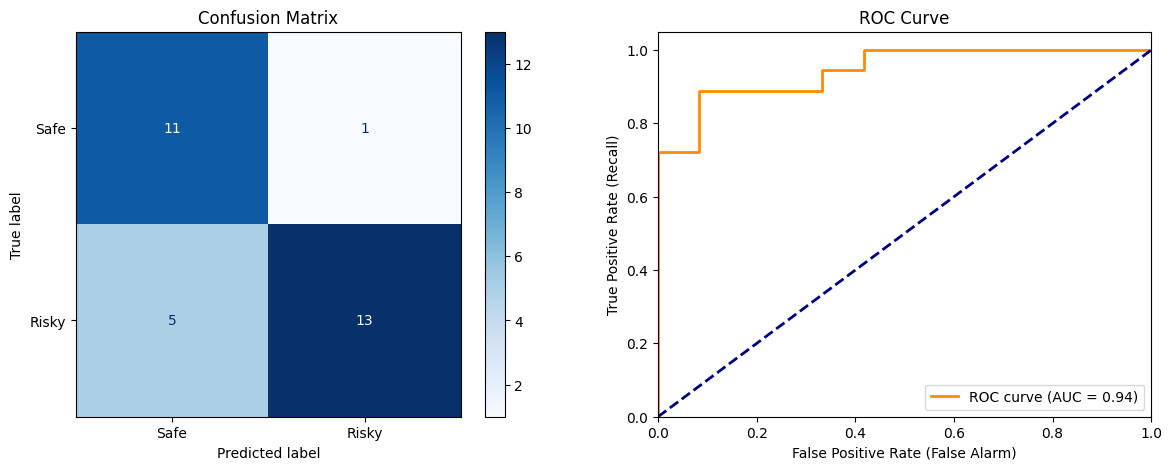

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
# Confusion Matrix Plot
disp.plot(cmap='Blues', ax=ax[0])
ax[0].set_title("Confusion Matrix")

# ROC Plot
ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[1].set_xlim([0.0, 1.0])
ax[1].set_ylim([0.0, 1.05])
ax[1].set_xlabel('False Positive Rate (False Alarm)')
ax[1].set_ylabel('True Positive Rate (Recall)')
ax[1].set_title('ROC Curve')
ax[1].legend(loc="lower right")

plt.show()

### 3.6 Classification Report

In [24]:
print("Detailed Classification Metrics:")
print(classification_report(y_test, y_pred, target_names=['Safe', 'Risky']))

Detailed Classification Metrics:
              precision    recall  f1-score   support

        Safe       0.69      0.92      0.79        12
       Risky       0.93      0.72      0.81        18

    accuracy                           0.80        30
   macro avg       0.81      0.82      0.80        30
weighted avg       0.83      0.80      0.80        30



**Metric Definitions for Finance:**
* **False Positive (Type I):** we flagged a safe customer as risky.
  (Cost: lost business, angry customer.)
* **False Negative (Type II):** we lent money to a risky customer who defaulted.
  (Cost: principal loss.)
* **Recall (Sensitivity):** out of all actual defaults, how many did we catch?
* **Precision:** out of everyone we refused, how many would really have defaulted?

Read the confusion matrix above: accuracy is 0.80 and AUC is 0.94, but the model still makes
both kinds of error.

**AUC of 0.94 does not mean "94% right".** It means that if you draw one defaulter and one
payer at random, the model gives the defaulter the higher score 94% of the time. It is a
statement about *ranking*, and it says nothing at all about where you should cut. That is
Part 5.

## 3.7 "Accuracy is dangerous" - now let us actually show it

Everything above ran on a **50/50** dataset. Half the customers defaulted. No real credit
book looks like that, and on balanced data the 99%-accurate-but-useless argument cannot even
be demonstrated - there is no majority class large enough to hide behind.

So here is a realistic book: **3,000 customers, 3.3% of whom default.**

In [25]:
X_imb, y_imb = make_blobs(n_samples=[2900, 100], centers=[[0, 0], [0, 6]],
                          random_state=11, cluster_std=[3.0, 2.5])

book = pd.DataFrame({'annual_income': (X_imb[:, 0] * 4200 + 48000).round(0),
                     'card_balance': (X_imb[:, 1] * 210 + 2400).round(0)})

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    book, y_imb, test_size=0.3, random_state=42, stratify=y_imb)

print(book.describe().round(0).to_string())
print()
print('default rate: %.1f%%  (%d defaulters out of %d)'
      % (100 * y_imb.mean(), y_imb.sum(), len(y_imb)))

       annual_income  card_balance
count         3000.0        3000.0
mean         47925.0        2454.0
std          12696.0         666.0
min           5639.0         203.0
25%          39363.0        2007.0
50%          47748.0        2442.0
75%          56699.0        2883.0
max          90172.0        5025.0

default rate: 3.3%  (100 defaulters out of 3000)


In [26]:
# The "dumb" model: refuse to think, predict 'no default' for everybody.
dumb = np.zeros_like(yb_test)
print('THE DUMB MODEL')
print('  accuracy : %.3f   <- looks excellent' % accuracy_score(yb_test, dumb))
print('  recall   : %.3f   <- it caught zero of the %d defaulters'
      % (recall_score(yb_test, dumb, zero_division=0), yb_test.sum()))
print('  AUC      : %.3f   <- a constant score cannot rank anything'
      % roc_auc_score(yb_test, dumb))

# A real model. StandardScaler and LogisticRegression inside a Pipeline, so the scaler is
# fitted on the training fold only and nothing leaks from the test set.
credit_lr = make_pipeline(StandardScaler(), LogisticRegression()).fit(Xb_train, yb_train)
yb_pred = credit_lr.predict(Xb_test)
yb_proba = credit_lr.predict_proba(Xb_test)[:, 1]
tn, fp, fn, tp = confusion_matrix(yb_test, yb_pred).ravel()

print()
print('LOGISTIC REGRESSION')
print('  accuracy : %.3f   <- barely better than the dumb model' % accuracy_score(yb_test, yb_pred))
print('  AUC      : %.3f   <- and yet the ranking is genuinely good' % roc_auc_score(yb_test, yb_proba))
print('  recall   : %.3f   <- it caught %d of the %d defaulters' % (tp / (tp + fn), tp, tp + fn))
print('  confusion: TN=%d  FP=%d  FN=%d  TP=%d' % (tn, fp, fn, tp))

THE DUMB MODEL
  accuracy : 0.967   <- looks excellent
  recall   : 0.000   <- it caught zero of the 30 defaulters
  AUC      : 0.500   <- a constant score cannot rank anything

LOGISTIC REGRESSION
  accuracy : 0.971   <- barely better than the dumb model
  AUC      : 0.942   <- and yet the ranking is genuinely good
  recall   : 0.200   <- it caught 6 of the 30 defaulters
  confusion: TN=868  FP=2  FN=24  TP=6


**Read those numbers together, because this is the most important point of the
week.**

| | dumb model | logistic regression |
|---|---|---|
| accuracy | 0.967 | 0.971 |
| recall | 0.000 | 0.200 |
| AUC | 0.500 | 0.942 |

On **accuracy** the two models are indistinguishable - the real model buys you 0.4 percentage
points. If accuracy were your KPI you would conclude the model is worthless and stop.

But its **AUC is 0.942**. The model ranks customers by risk almost perfectly. All of that
information is present; `predict()` is throwing it away, because `predict()` cuts at 0.5 and
in a 3%-default book almost nobody scores above 0.5.

So the model is good and the **decision rule** is broken. Fixing the decision rule is Part 5,
and on this test set it is worth about **EUR 329,000**.

# Part 4: Nearest Neighbours (Peer Group Analysis)

KNN is intuitive: "show me your friends, and I'll tell you your risk score."

KNN doesn't learn coefficients. It remembers data. This makes it perfect for the
**non-linear fraud data** that Logistic Regression failed on.

It also makes it the model most easily destroyed by a units mistake - which is section 4.4.

## 4.1 A first look: KNN on the credit data

In [27]:
knn_blob=KNeighborsClassifier(n_neighbors=5,p=2)
knn_blob.fit(X_blob,y_blob)

KNeighborsClassifier()

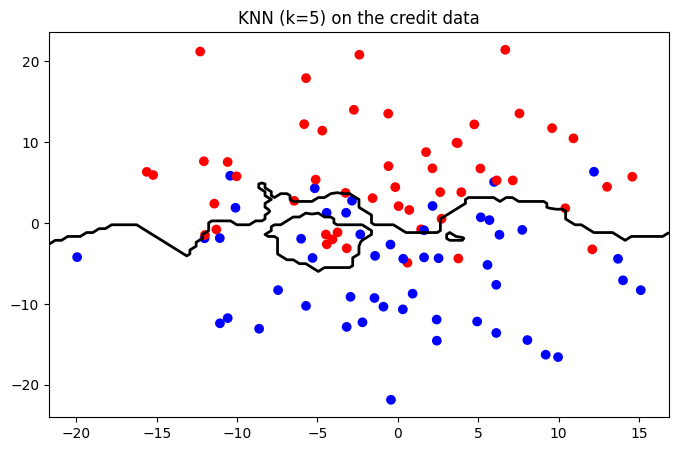

In [28]:
plt.figure(figsize=[8,5])
plt.scatter(X_blob[:,0],X_blob[:,1],c=y_blob,cmap='bwr')
plot_decision_function(knn_blob,color='k')
plt.title("KNN (k=5) on the credit data")
plt.show()

**Observation:** notice the boundary is "wiggly". KNN adapts locally to data.

## 4.2 The effect of k on the boundary

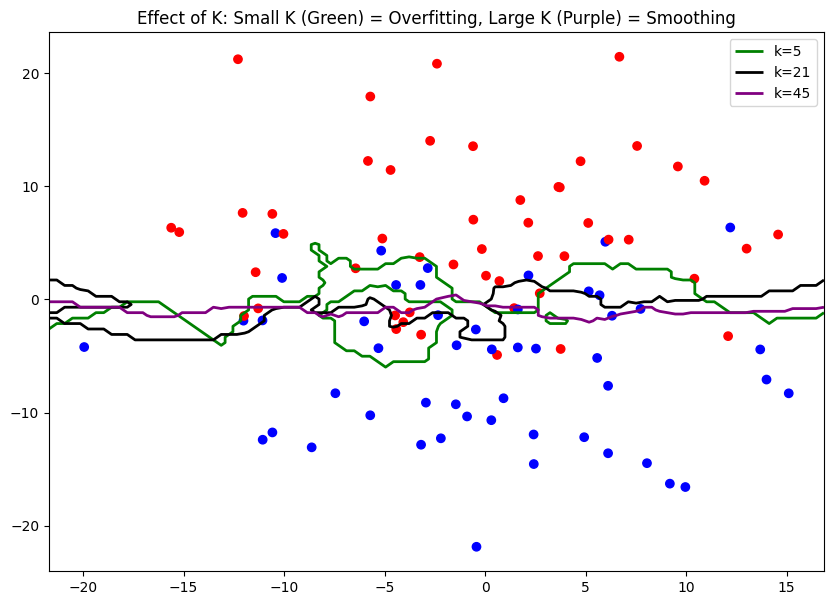

In [29]:
plt.figure(figsize=[10,7])
ax = plt.gca()
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob,cmap='bwr')
h = {}
para_list=[(5,'green'),(21,'black'),(45,'purple')]

for no_neighbor_i,color_i in para_list:
  knn = KNeighborsClassifier(n_neighbors=no_neighbor_i)
  knn.fit(X_blob, y_blob)
  fig_knn=plot_decision_function(knn,ax=ax,color=color_i)
  h[no_neighbor_i],_ = fig_knn.legend_elements()

ax.legend([h[i][0] for i,j in para_list], ['k={}'.format(i) for i,j in para_list])
plt.title("Effect of K: Small K (Green) = Overfitting, Large K (Purple) = Smoothing")
plt.show()

## 4.3 KNN on the fraud ring

KNN works exceptionally well on non-linear data without needing polynomial features.

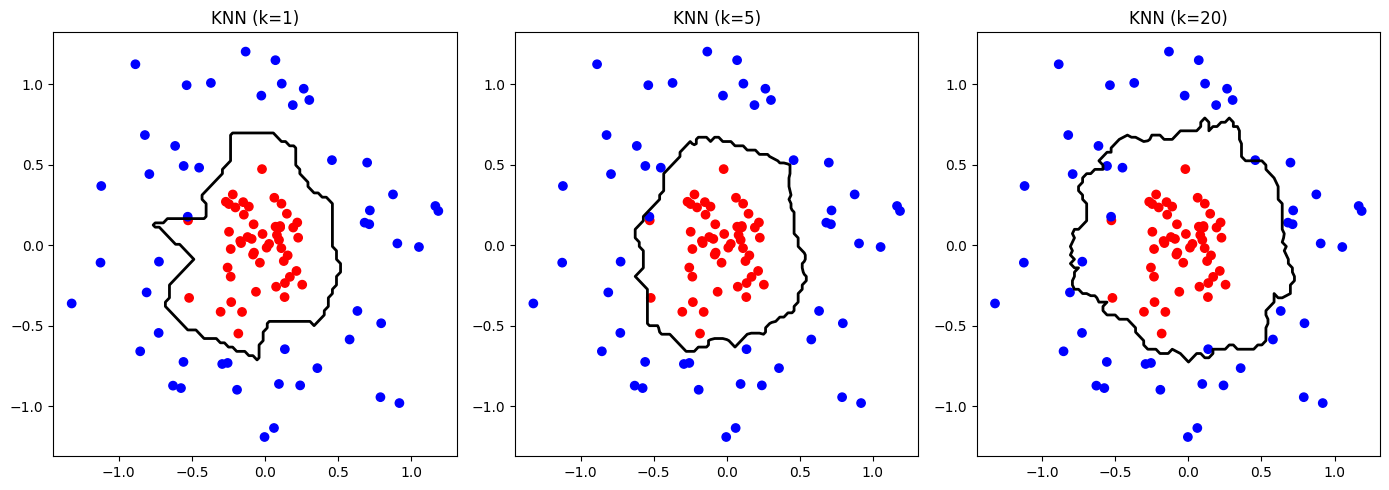

In [30]:
# Compare K values
plt.figure(figsize=[14,5])

k_values = [1, 5, 20]

for i, k in enumerate(k_values):
    ax = plt.subplot(1, 3, i+1)
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_circle, y_circle)

    plt.scatter(X_circle[:,0],X_circle[:,1],c=y_circle,cmap='bwr')
    plot_decision_function(knn, ax=ax, color='k')
    plt.title(f"KNN (k={k})")

plt.tight_layout()
plt.show()

**The Bias-Variance Tradeoff in KNN:**
* **k=1:** the boundary is jagged. It memorizes noise (overfitting).
* **k=20:** the boundary is smooth. It ignores local nuances (underfitting).
* **Financial Context:** small 'k' might flag a customer as risky just because one outlier
  neighbour defaulted. Large 'k' is more robust but might miss niche fraud patterns.

Those are the claims. Section 4.5 **measures** them - and one of the two turns out to be
conditional rather than universal.

## 4.4 The units problem

Every plot so far has said **"Normalized"** on the axis. That was doing a lot of work.

Slide 79 says plainly that "features must be rescaled for this type of models", and so far
you have had no reason to believe it matters. `make_blobs` hands you numbers that are already
on a common scale, so scaling looks like a formality. Real data never arrives that way.

Below are the **same 600 customers**, from the same generator, written out in the units a
bank would actually store them in:

* `annual_income` in euros - spread about **13,300**
* `card_balance` in euros - spread about **480**

Nothing about the customers changed. Only the units. Watch what that does to KNN.

In [31]:
Xc, yc = make_blobs(n_samples=600, centers=2, random_state=100, cluster_std=7)

credit = pd.DataFrame({'annual_income': (Xc[:, 0] * 1825 + 52000).round(0),
                       'card_balance' : (Xc[:, 1] * 52   + 1800).round(0)})
default = yc                       # 1 = defaulted

Xtr, Xte, ytr, yte = train_test_split(credit, default, test_size=0.3,
                                      random_state=42, stratify=default)

print(credit.describe().round(0).to_string())
ratio = credit.annual_income.std() / credit.card_balance.std()
print()
print('income has %.0fx the spread of balance' % ratio)
print('Euclidean distance SQUARES that, so income weighs about %.0fx as much' % ratio ** 2)

       annual_income  card_balance
count          600.0         600.0
mean         51552.0        1852.0
std          13320.0         477.0
min          12297.0         401.0
25%          42552.0        1512.0
50%          51084.0        1854.0
75%          60536.0        2179.0
max         102869.0        3209.0

income has 28x the spread of balance
Euclidean distance SQUARES that, so income weighs about 781x as much


In [32]:
knn_raw    = KNeighborsClassifier(n_neighbors=15).fit(Xtr, ytr)
knn_scaled = make_pipeline(StandardScaler(),
                           KNeighborsClassifier(n_neighbors=15)).fit(Xtr, ytr)

acc_raw    = accuracy_score(yte, knn_raw.predict(Xte))
acc_scaled = accuracy_score(yte, knn_scaled.predict(Xte))

print('KNN (k=15) on RAW euros    : %.3f' % acc_raw)
print('KNN (k=15) with a Scaler   : %.3f' % acc_scaled)
print('difference                 : %+.3f' % (acc_scaled - acc_raw))

# Which feature is the raw model actually using?
inc_only = KNeighborsClassifier(15).fit(Xtr[['annual_income']], ytr)
bal_only = KNeighborsClassifier(15).fit(Xtr[['card_balance']], ytr)
print()
print('income ALONE               : %.3f'
      % accuracy_score(yte, inc_only.predict(Xte[['annual_income']])))
print('balance ALONE              : %.3f   <- the better feature, by a mile'
      % accuracy_score(yte, bal_only.predict(Xte[['card_balance']])))

KNN (k=15) on RAW euros    : 0.672
KNN (k=15) with a Scaler   : 0.744
difference                 : +0.072

income ALONE               : 0.544
balance ALONE              : 0.744   <- the better feature, by a mile


**Conclusion: scaling is not a refinement, it is a correctness requirement.**

Look at the last two numbers. `card_balance` **on its own** scores 0.744. The two-feature
model on raw euros scores **0.672** - *worse than using the good feature alone*.

Adding a second, genuinely informative column made the model worse. Not because the column
was bad, but because it was **denominated in euros of income rather than euros of balance**,
and Euclidean distance cannot tell the difference between "a big number" and "an important
number". The 28x spread becomes a 781x weight once you square it, so every neighbourhood is
decided by income and the balance column is never consulted.

Put a `StandardScaler` in front and the score goes back to 0.744.

**Two rules follow, and both matter for the homework:**

1. **Any distance-based model must be scaled.** KNN, k-means (Week 3), SVM. Logistic
   regression will survive without it; KNN will not.
2. **Do the scaling inside a `Pipeline`, never with `fit_transform` on the whole dataset.**
   `make_pipeline(StandardScaler(), KNeighborsClassifier(15))` fits the scaler on the
   training fold only. Scaling first and splitting afterwards leaks the test set's mean and
   standard deviation into training - the same look-ahead mistake as Week 1.

**In the homework you run KNN on the `Default` dataset, where `balance` has a spread of
about 480 and `income` about 13,300.** That is this exact situation. If you skip the scaler,
your KNN is an income-only model and your comparison against logistic regression is
meaningless.

## 4.5 Choosing k honestly

Slide 86 says small k overfits and large k underfits. So far we have only *looked at
boundaries* - a wiggly line is suggestive, not evidence. Let us score both ends on data the
model has never seen.

We do it on **both** datasets, because the answer is not the same on each.

In [33]:
k_grid = [1, 3, 5, 9, 15, 25, 45, 75, 125, 205, 305]

# dataset A: the overlapping credit book (scaled, as we just learned)
credit_train, credit_test = [], []
for k in k_grid:
    m = make_pipeline(StandardScaler(), KNeighborsClassifier(k)).fit(Xtr, ytr)
    credit_train.append(accuracy_score(ytr, m.predict(Xtr)))
    credit_test.append(accuracy_score(yte, m.predict(Xte)))

# dataset B: the well-separated fraud ring
Xf, yf = make_circles(n_samples=600, factor=.1, noise=.2, random_state=100)
Ftr, Fte, gtr, gte = train_test_split(Xf, yf, test_size=0.3, random_state=42, stratify=yf)
fraud_train, fraud_test = [], []
for k in k_grid:
    m = KNeighborsClassifier(k).fit(Ftr, gtr)
    fraud_train.append(accuracy_score(gtr, m.predict(Ftr)))
    fraud_test.append(accuracy_score(gte, m.predict(Fte)))

out = pd.DataFrame({'k': k_grid,
                    'credit_train': credit_train, 'credit_test': credit_test,
                    'fraud_train': fraud_train,   'fraud_test': fraud_test})
print(out.round(3).to_string(index=False))

  k  credit_train  credit_test  fraud_train  fraud_test
  1         1.000        0.706        1.000       0.994
  3         0.852        0.722        0.981       0.983
  5         0.812        0.750        0.981       0.983
  9         0.812        0.756        0.979       0.983
 15         0.824        0.744        0.981       0.983
 25         0.819        0.739        0.981       0.983
 45         0.817        0.728        0.974       0.983
 75         0.812        0.733        0.957       0.978
125         0.812        0.722        0.745       0.722
205         0.802        0.750        0.500       0.500
305         0.790        0.728        0.500       0.500


For comparison - logistic regression on the fraud ring: 0.467


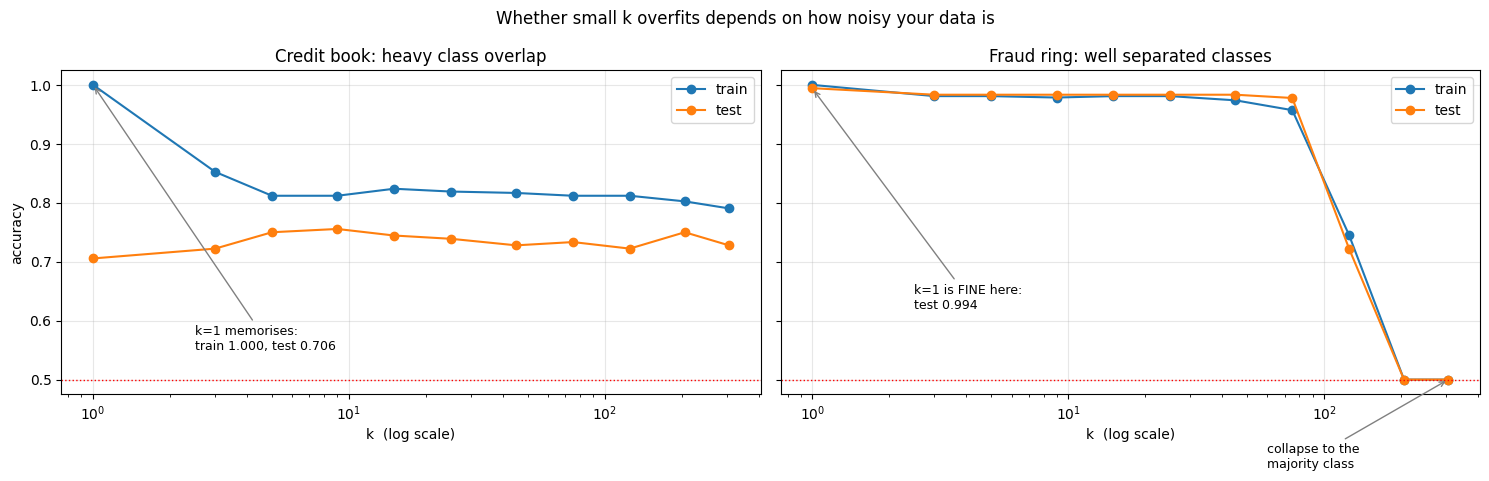

In [34]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

ax[0].plot(k_grid, credit_train, marker='o', label='train')
ax[0].plot(k_grid, credit_test, marker='o', label='test')
ax[0].set_title('Credit book: heavy class overlap')
ax[0].annotate('k=1 memorises:\ntrain 1.000, test 0.706',
               xy=(1, 1.0), xytext=(2.5, 0.55),
               arrowprops=dict(arrowstyle='->', color='grey'), fontsize=9)

ax[1].plot(k_grid, fraud_train, marker='o', label='train')
ax[1].plot(k_grid, fraud_test, marker='o', label='test')
ax[1].set_title('Fraud ring: well separated classes')
ax[1].annotate('k=1 is FINE here:\ntest 0.994',
               xy=(1, 0.994), xytext=(2.5, 0.62),
               arrowprops=dict(arrowstyle='->', color='grey'), fontsize=9)
ax[1].annotate('collapse to the\nmajority class',
               xy=(305, 0.5), xytext=(60, 0.35),
               arrowprops=dict(arrowstyle='->', color='grey'), fontsize=9)

for a in ax:
    a.set_xscale('log')
    a.set_xlabel('k  (log scale)')
    a.axhline(0.5, ls=':', c='red', lw=1)
    a.legend()
    a.grid(alpha=0.3)
ax[0].set_ylabel('accuracy')
plt.suptitle('Whether small k overfits depends on how noisy your data is')
plt.tight_layout()
plt.show()

lr_fraud = LogisticRegression().fit(Ftr, gtr)
print('For comparison - logistic regression on the fraud ring: %.3f'
      % accuracy_score(gte, lr_fraud.predict(Fte)))

**Conclusion - and it is more interesting than the slide.**

**Left panel, the credit book.** At `k=1` the training accuracy is exactly **1.000**, and it
could not be anything else: the nearest neighbour of a training point is the point itself, so
the model reproduces its own training data perfectly. Test accuracy is **0.706**, the worst
of any k we tried. A gap of 0.294 between train and test *is* overfitting, expressed as a
single number. The best k is 9, at 0.756.

**Right panel, the fraud ring.** At `k=1` the training accuracy is also 1.000 - but the test
accuracy is **0.994**. There is no gap, and no overfitting. The two rings barely overlap, so
your nearest neighbour is almost always the same class as you.

So **"small k overfits" is not a law**. k=1 memorises the training data always; whether that
*hurts* depends on how much the classes overlap. Noisy, overlapping data punishes small k;
clean, separated data does not. This is why you tune k on a validation set instead of
learning a rule of thumb.

**Large k does behave as advertised, in both panels.** Push k to 205 on the fraud data and
both curves drop to **0.500** - the neighbourhood is so wide that every point sees the whole
dataset and every prediction converges to the majority class. That is underfitting in its
purest form.

**One more number worth pausing on.** Logistic regression scores **0.467** on the fraud ring
- *below a coin toss*. This is the quantitative version of the failed straight line in
section 2.3. The right model class matters more than any amount of hyperparameter tuning.

# Part 5: The Threshold, the Costs, and What a Probability Is Worth

*(Slides 87-90.)*

We left Part 3 with a puzzle. The logistic regression on the imbalanced credit book had an
AUC of 0.942 and caught **6 of 30** defaulters. The model is good. Something else is broken.

That something is `predict()`. It cuts the predicted probability at **0.5**, and nobody chose
0.5 for this problem. It is a library default. In a book where the base rate is 3.3%, a
customer who is *ten times* riskier than average still only scores about 0.33 - and gets
approved.

## 5.1 The threshold is a business decision

The credit committee gives you two numbers:

| error | what it means | cost |
|---|---|---|
| **False negative** | we lent to someone who defaulted | **EUR 20,000** |
| **False positive** | we refused someone who would have repaid | **EUR 1,000** |

A missed default costs twenty refusals. Now we can stop guessing and compute.

In [35]:
COST_FN = 20000     # we lent to a defaulter: we lose the principal
COST_FP = 1000      # we refused a good customer: we lose the margin

rows = []
for t in np.arange(0.02, 0.61, 0.02):
    pred = (yb_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(yb_test, pred).ravel()
    rows.append({'threshold': round(t, 2), 'FN': fn, 'FP': fp,
                 'recall': tp / (tp + fn),
                 'cost': COST_FN * fn + COST_FP * fp})

costs = pd.DataFrame(rows)
print(costs.to_string(index=False))

best = costs.loc[costs['cost'].idxmin()]
cost_at_50 = costs.loc[np.isclose(costs['threshold'], 0.50), 'cost'].iloc[0]
print()
print('cheapest threshold : %.2f  ->  EUR %10s   (recall %.2f)'
      % (best.threshold, '{:,.0f}'.format(best.cost), best.recall))
print('the default   0.50 :      ->  EUR %10s   (recall %.2f)'
      % ('{:,.0f}'.format(cost_at_50), costs.loc[np.isclose(costs["threshold"], 0.50), "recall"].iloc[0]))
print('cost of not choosing:     ->  EUR %10s' % '{:,.0f}'.format(cost_at_50 - best.cost))

 threshold  FN  FP   recall   cost
      0.02   2 209 0.933333 249000
      0.04   3 128 0.900000 188000
      0.06   3  93 0.900000 153000
      0.08   8  70 0.733333 230000
      0.10  10  52 0.666667 252000
      0.12  11  40 0.633333 260000
      0.14  12  31 0.600000 271000
      0.16  13  26 0.566667 286000
      0.18  14  23 0.533333 303000
      0.20  14  20 0.533333 300000
      0.22  14  15 0.533333 295000
      0.24  15  14 0.500000 314000
      0.26  15  11 0.500000 311000
      0.28  17   7 0.433333 347000
      0.30  18   7 0.400000 367000
      0.32  20   6 0.333333 406000
      0.34  20   6 0.333333 406000
      0.36  20   6 0.333333 406000
      0.38  20   6 0.333333 406000
      0.40  20   4 0.333333 404000
      0.42  21   4 0.300000 424000
      0.44  21   4 0.300000 424000
      0.46  22   4 0.266667 444000
      0.48  24   2 0.200000 482000
      0.50  24   2 0.200000 482000
      0.52  24   2 0.200000 482000
      0.54  24   0 0.200000 480000
      0.56  25   0 0

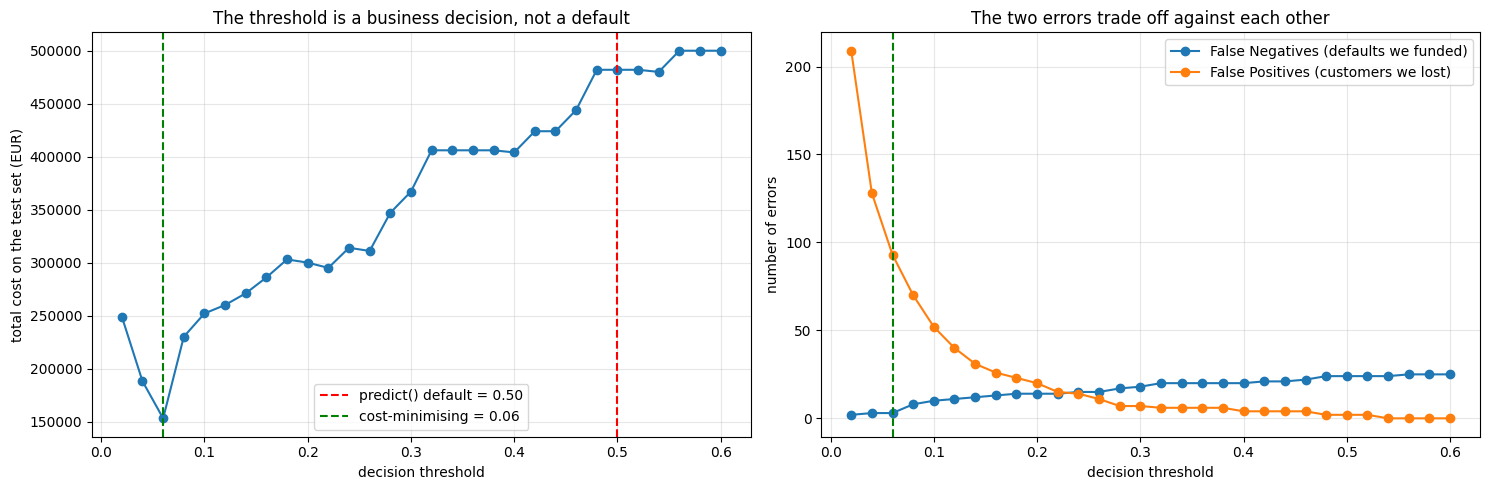

In [36]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].plot(costs['threshold'], costs['cost'], marker='o')
ax[0].axvline(0.5, ls='--', c='red', label='predict() default = 0.50')
ax[0].axvline(best.threshold, ls='--', c='green',
              label='cost-minimising = %.2f' % best.threshold)
ax[0].set_xlabel('decision threshold')
ax[0].set_ylabel('total cost on the test set (EUR)')
ax[0].set_title('The threshold is a business decision, not a default')
ax[0].legend()
ax[0].grid(alpha=0.3)

ax[1].plot(costs['threshold'], costs['FN'], marker='o', label='False Negatives (defaults we funded)')
ax[1].plot(costs['threshold'], costs['FP'], marker='o', label='False Positives (customers we lost)')
ax[1].axvline(best.threshold, ls='--', c='green')
ax[1].set_xlabel('decision threshold')
ax[1].set_ylabel('number of errors')
ax[1].set_title('The two errors trade off against each other')
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Conclusion.** The cheapest threshold is **0.06**, not 0.50, and the difference is
**EUR 329,000** on 900 customers - roughly EUR 366 per application, from changing one number.

Recall goes from **0.20 to 0.90**: we go from catching 6 of the 30 defaulters to catching 27.
We pay for it with 93 false positives instead of 2, but at a 20:1 cost ratio that is a
bargain.

Three things follow, and they are the message of the whole session:

1. **The model did not change.** Same coefficients, same probabilities, same AUC. Only the
   decision rule moved. AUC could not have told you any of this - it is invariant to the
   threshold by construction.
2. **You cannot choose a threshold without the costs.** If someone asks you to "optimise the
   model" without telling you what each error costs, that is the first question to ask back.
3. **Notice the curve turns up again below 0.06.** There is a genuine interior optimum - more
   recall is not free. At t=0.02 you catch 28 defaulters but refuse 209 good customers, and
   the total cost rises again.

**And the health warning:** we swept the threshold on the *test* set, for speed. In practice
you choose it on a **validation** set and report the cost on the test set. Choosing it on the
test set is the same mistake as tuning alpha on the test set in the Week 1 homework.

## 5.2 Is that number actually a probability?

Everything in 5.1 assumed `predict_proba` returns something meaningful. "Cut at 0.06" only
makes sense if 0.06 really means *a 6% chance of default*.

A model whose probabilities are trustworthy in this sense is called **calibrated**. Let us
check two models on the same data.

In [37]:
lr_model  = make_pipeline(StandardScaler(), LogisticRegression()).fit(Xb_train, yb_train)
knn_model = make_pipeline(StandardScaler(), KNeighborsClassifier(25)).fit(Xb_train, yb_train)

for name, m in [('Logistic Regression', lr_model), ('KNN (k=25)', knn_model)]:
    p = m.predict_proba(Xb_test)[:, 1]
    print('%-22s accuracy %.3f   AUC %.3f   Brier %.4f   distinct probabilities: %d'
          % (name, accuracy_score(yb_test, m.predict(Xb_test)),
             roc_auc_score(yb_test, p), brier_score_loss(yb_test, p), len(np.unique(p))))

print()
print('The Brier score is the mean squared error of the probabilities. Lower is better.')
print('A model that always predicts the base rate (0.033) would score %.4f.'
      % brier_score_loss(yb_test, np.full(len(yb_test), yb_test.mean())))

Logistic Regression    accuracy 0.971   AUC 0.942   Brier 0.0219   distinct probabilities: 900
KNN (k=25)             accuracy 0.970   AUC 0.892   Brier 0.0247   distinct probabilities: 17

The Brier score is the mean squared error of the probabilities. Lower is better.
A model that always predicts the base rate (0.033) would score 0.0322.


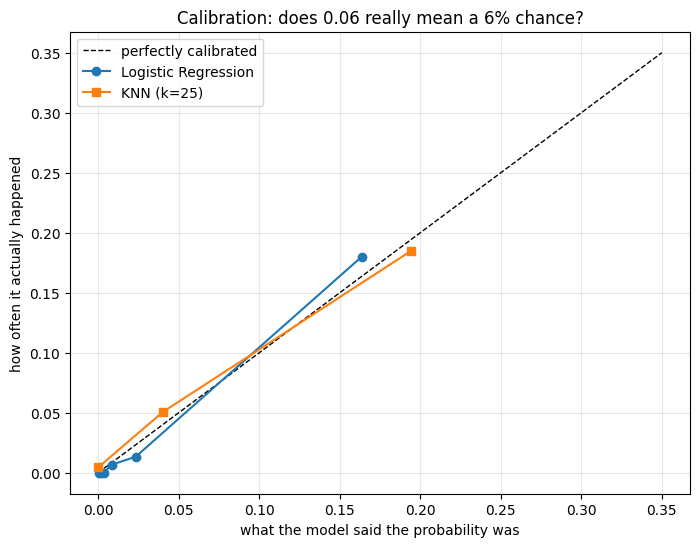

In [38]:
plt.figure(figsize=(8, 6))
plt.plot([0, 0.35], [0, 0.35], 'k--', lw=1, label='perfectly calibrated')

for name, m, mk in [('Logistic Regression', lr_model, 'o'), ('KNN (k=25)', knn_model, 's')]:
    p = m.predict_proba(Xb_test)[:, 1]
    observed, predicted = calibration_curve(yb_test, p, n_bins=6, strategy='quantile')
    plt.plot(predicted, observed, marker=mk, label=name)

plt.xlabel('what the model said the probability was')
plt.ylabel('how often it actually happened')
plt.title('Calibration: does 0.06 really mean a 6% chance?')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Conclusion, and it is not the one you might expect.**

Both models sit close to the diagonal, so neither is badly *biased*. The difference is in the
last column of the table above:

* Logistic regression produces **900 distinct probability values** - one per customer.
* KNN with k=25 produces **17**.

That is not a rounding detail, it is structural. KNN's "probability" is *the fraction of your
25 neighbours who defaulted*. It can only ever return 0/25, 1/25, 2/25... so the finest
distinction it can draw is 0.04.

**Now go back to section 5.1.** Our cost-optimal threshold was **0.06**. On the KNN model,
0.06 falls between 1/25 = 0.04 and 2/25 = 0.08 - there is nothing there to cut. You cannot
implement the optimal policy with that model, no matter how good its AUC is.

So the choice of model determines whether the number you get back is a **probability you can
act on** or merely a **score you can rank with**. In a regulated setting - IFRS 9 expected
credit loss, Basel PD estimates - you are required to produce the former. That is a large
part of why logistic regression is still running the credit industry.

If you do need calibrated probabilities from a model that does not produce them naturally,
`sklearn.calibration.CalibratedClassifierCV` will fit a correction on a held-out fold. We do
not need it here.

---
# What to take away

| | |
|---|---|
| **Logistic regression** | interpretable, calibrated, still the industry standard. Fails on non-linear structure unless you engineer features for it. |
| **Regularization** | `C` is the inverse of Week 1's alpha. L1 selects features, L2 only shrinks them. **Scale before you penalise.** |
| **Accuracy** | meaningless on imbalanced data. A 96.7% accurate model caught zero defaults. |
| **AUC** | measures ranking, not decisions. Invariant to the threshold. |
| **KNN** | no training, all memory. **Must be scaled.** Whether small k overfits depends on class overlap. |
| **The threshold** | a business decision that needs a cost matrix. Worth EUR 329,000 here. |
| **Calibration** | ask whether your model can even express the probability you want to act on. |

The two habits to carry into every week from here:

1. **Put the preprocessing in a `Pipeline`.** It is not a style preference - it is what keeps
   the test set out of your training.
2. **Ask what an error costs** before you ask how accurate the model is.

# Homework: Week 2 - The Credit Default Challenge

## Dataset:
We will use the **Default** dataset. It contains data on credit card default, including
student status, bank balance, and annual income.

**URL:** https://raw.githubusercontent.com/JWarmenhoven/ISLR-python/master/Notebooks/Data/Default.xlsx

## Part 1: EDA & Balance
1.  **Load Data:** Load the XLSX. Encode 'default' and 'student' to 0/1.
2.  **The Imbalance:** Calculate the percentage of defaulters. What accuracy would a "dumb"
    model that predicts 'No Default' for everyone achieve? (Section 3.7 is the worked
    template for this.)
3.  **Visualization:** Boxplot the 'balance' for Defaulters vs Non-Defaulters. Do defaulters
    tend to carry higher balances?
4.  **Check the scales.** Print `df.std()`. How many times larger is the spread of `income`
    than that of `balance`? Keep the number - you will need it in Part 3.

## Part 2: Logistic Regression & Interpretability
1.  **Split:** Train/Test split (70/30). Use `stratify=y` - with a 3% base rate an unlucky
    split can leave you almost no defaulters in the test set.
2.  **Fit:** Train a standard Logistic Regression **inside a `Pipeline` with a
    `StandardScaler`**. Do not call `fit_transform` on the full dataset and split afterwards
    - that leaks the test set into training and will cost you marks.
3.  **Coefficients:** Print the model coefficients. Which variable (Balance or Income)
    creates more risk? Does being a Student increase or decrease risk according to the model?
    (Note: because you scaled, the coefficients are now directly comparable to each other.
    Say why that would not have been true on the raw data.)
4.  **Feature Selection (Lasso):** Fit a Logistic Regression with `penalty='l1'` and
    `solver='liblinear'`. Try a small `C` (e.g. 0.01). Did any coefficients drop to zero?
    What does this imply? (See the deprecation note at the top of this notebook if your
    scikit-learn warns about `penalty`.)

## Part 3: The Metric Battle (LogReg vs KNN)
1.  **Fit KNN:** Train a KNN model (try k=9), **scaled, in a `Pipeline`**. Then, for
    comparison, fit one on the raw unscaled features and report both scores. Explain the gap
    using the standard deviations you computed in Part 1.4.
2.  **Comprehensive Metrics:** Plot the confusion matrix for both models side-by-side.
    Instead of just Accuracy, print a DataFrame comparing Recall, Precision, F1-Score and
    ROC-AUC for both models (focusing on the "Default=1" class).
3.  **The Trade-off Analysis:**
    - **Recall:** which model is safer (misses fewer defaults)?
    - **Precision:** which model is more efficient (falsely accuses fewer good customers)?
    - **F1-Score:** which model provides the best balance?
4.  **Visualizing Performance:** Plot the ROC curve for both models on the same graph. Which
    curve is closer to the top-left corner?
5.  **The Verdict:** As a Risk Manager, you must choose one model to deploy.
    - **Scenario A:** your bank is conservative and fears losing principal (needs high
      Recall). Which model do you pick?
    - **Scenario B:** your bank wants to grow and fears rejecting good customers (needs high
      Precision). Which model do you pick?
    - **Final Decision:** considering Explainability (Part 2) and Performance (Part 3), which
      model is the most realistic choice for a regulated financial institution?

## Part 4: The Threshold
1.  Take your **logistic regression** probabilities on the test set.
2.  Assume a false negative costs **EUR 20,000** and a false positive **EUR 1,000**. Sweep
    the threshold from 0.02 to 0.60 and compute the total cost at each.
3.  Report the cost-minimising threshold, the cost at the default 0.50, and the difference.
4.  How many distinct probability values does your **KNN** model produce? Could you implement
    your optimal threshold with it? Explain in two sentences.